<h1><img src="../../../icons/tk_full_logo.svg" width="80" /> AI Lab Education</h1>

# 🦓 Teach a Model to Formalize: GRPO on Zebra Puzzles

In notebook 03 the agents debated how to give a small model reasoning ability:
reinforcement learning on verifiable rewards, or distillation from a larger
model. This notebook runs the first answer end to end, on your own hardware,
with your own model.

The task is a zebra puzzle — "there are five houses, the Englishman lives in the
yellow one, the dog is next door to the fox…" — and the twist is *what we ask
the model to do with it*. The model never solves the puzzle. It **translates**
each English clue into a formal rule, and a constraint solver deduces the grid
from those rules. The model formalizes; the machine deduces.

That division of labour is the point. It is how knowledge graphs get built from
documents, how questions become SQL, how contracts become checkable records. The
puzzle is just a gym where every answer can be verified mechanically — which is
exactly what reinforcement learning needs and what most real tasks lack.

## 🎯 What You'll Build

- **A rule language** for zebra puzzles, and a CSP solver that executes it
- **A reward with no labels** — the solver grades the model's translation by
  counting how many cells of the deduced grid are correct
- **A GRPO training loop** where the model improves by comparing its own attempts
  against each other, never by imitating a reference answer
- **Two evaluations** — one on puzzles from our generator, one on a public
  benchmark written by other people — to separate memorising a format from
  learning to translate
- **The full platform loop** — merge the adapter, register it in MLflow so every
  GPU node can reach it, serve it on vLLM, and query it through the LLM Gateway

## ⏱ What it costs

Demo scale (the default) is about an hour end to end on a single GPU, and it
produces a real, measurable improvement. `FULL_RUN = True` restores
experiment scale — 250 steps and 4× larger evaluations — which is where the
literature's larger gains live. Both are honest; only one fits in a coffee break.

**Prerequisites**: the `fine-tuning` venv, one GPU with roughly 20 GB free, and
the platform services (MLflow, LLM Gateway) that notebook 00 validated.

---
## Setup

**What**: Confirm the libraries this notebook needs are present.

**Why**: Three pieces do the work — **Unsloth** (memory-efficient LoRA fine-tuning),
**TRL** (the GRPO trainer itself), and **python-constraint** (the CSP solver that
turns rules into a grid). On thinkube's `fine-tuning` venv all three are already
installed, so this cell stays commented out.

**How**: Uncomment only if you are running somewhere else. Installing over a
working venv is the most common way to break a GPU stack — the versions here are
pinned together deliberately.

In [19]:
# Uncomment to install:
# !pip install unsloth trl datasets python-constraint matplotlib

---
## 1. Imports and Environment

**What**: Load the libraries, and set two environment flags before Unsloth is
imported.

**Why**: The flags matter more than they look. Unsloth accelerates training by
compiling the model with `torch.compile`, which is a large win on mature
architectures. Qwen3.5 is a *hybrid-attention* model — most of its layers use a
linear-attention variant (GatedDeltaNet) rather than classic attention — and the
compiled path is not yet stable for it on this stack. Compilation is therefore
switched off, and section 9 explains the one leftover it does not cover.

Training runs slower without it. It also runs, which is the trade we want.

**How**: `UNSLOTH_COMPILE_DISABLE=1` must be set *before* `import unsloth`,
because the library reads it at import time. `zebra_dataset` is the local module
next to this notebook: it generates puzzles and knows nothing about models.

In [2]:
import json
import os
import random
import re
import time

# The compiled GRPO path is not yet stable for 2026 hybrid-attention models
# on this stack; run uncompiled (see the eager patch in the trainer cell)
os.environ["UNSLOTH_COMPILE_DISABLE"] = "1"
os.environ.pop("UNSLOTH_RETURN_LOGITS", None)
os.environ.pop("CUDA_LAUNCH_BLOCKING", None)

import torch
from unsloth import FastLanguageModel
from trl import GRPOConfig, GRPOTrainer
from datasets import Dataset, load_dataset

import zebra_dataset

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0827 03:13:11.222000 4238 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0827 03:13:11.241000 4238 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


🦥 Unsloth Zoo will now patch everything to make training faster!


<string>:1: FutureWarning: torch._dynamo.config.inline_inbuilt_nn_modules is deprecated and does not do anything, inline_inbuilt_nn_modules is always True. It will be removed in a future version of PyTorch.


---
## 2. Configuration

**What**: Every number that shapes the run, in one cell.

**Why**: Two settings deserve explanation.

`FULL_RUN` picks the scale. Demo (the default) is 500 training puzzles, 50 in
each evaluation set, and 60 GRPO steps — about an hour end to end. Full is
2,000 / 200 / 200 and 250 steps, which is an overnight job. Nothing else
changes between them, so a demo run is a faithful rehearsal of the real one.

`KL_BETA = 0.0` turns off the KL penalty. GRPO can hold the trained model near
its starting point by comparing against a frozen reference copy; setting beta to
zero removes both the penalty and the need to keep that second copy in memory.
That is TRL's own default, and for a short run on a narrow task the drift it
guards against is not the risk worth paying for.

The `EVAL_*` sampling values are not invented here — they are the settings the
Qwen3.5 model card publishes for non-thinking use, which is how the model is
meant to be run when you want a direct answer rather than visible deliberation.

**How**: Change `FULL_RUN` and re-run from this cell down. The two evaluation
sets keep separate seeds (`TRAIN_SEED`, `EVAL_SEED`) so no training puzzle can
appear in a test.

In [3]:
MODEL_NAME = "unsloth/Qwen3.5-4B"
MAX_SEQ_LEN = 3072
LORA_RANK = 16
LORA_ALPHA = 16

TRAIN_SEED = 1
EVAL_SEED = 99
SEED = 3407

NUM_GENERATIONS = 8
LEARNING_RATE = 1e-5
GRADIENT_ACCUMULATION = 4
# 0 keeps TRL's default (no KL penalty, no reference model)
KL_BETA = 0.0
MAX_COMPLETION_LENGTH = 800

# Qwen3.5 model-card sampling for non-thinking evaluation runs
EVAL_TEMPERATURE = 0.7
EVAL_TOP_P = 0.8
EVAL_TOP_K = 20

OUTPUT_DIR = "./zebra_rules_qwen35_4b"

# Demo scale by default: the whole notebook (train + evals + register + serve)
# fits in about an hour. FULL_RUN restores experiment scale.
FULL_RUN = False

if FULL_RUN:
    NUM_TRAIN_PUZZLES = 2000
    NUM_EVAL_PUZZLES = 200
    NUM_BENCH_PUZZLES = 200
    MAX_STEPS = 250
else:
    NUM_TRAIN_PUZZLES = 500
    NUM_EVAL_PUZZLES = 50
    NUM_BENCH_PUZZLES = 50
    MAX_STEPS = 60

print(f"Model: {MODEL_NAME}")
print(f"Scale: {'FULL' if FULL_RUN else 'DEMO'}")
print(f"Train: {NUM_TRAIN_PUZZLES}, Eval: {NUM_EVAL_PUZZLES}, Bench: {NUM_BENCH_PUZZLES}")
print(f"LoRA rank: {LORA_RANK}, LR: {LEARNING_RATE}, Steps: {MAX_STEPS}")

Model: unsloth/Qwen3.5-4B
Scale: DEMO
Train: 500, Eval: 50, Bench: 50
LoRA rank: 16, LR: 1e-05, Steps: 60


---
## 3. Load the Base Model

**What**: Fetch Qwen3.5-4B and attach a LoRA adapter to it.

**Why — where the weights come from**: The cell first asks MLflow whether this
model has been **mirrored** to the cluster. A mirrored model lives on JuiceFS,
which every GPU node can read, so it is fetched once and then loads locally
forever after. Without a mirror the notebook falls back to downloading ~9 GB
from Hugging Face onto whichever node happens to run this pod — again on the
next node, and the next. On a slow uplink that difference is the whole morning.
Mirror a model from thinkube-control → AI → Models, or with
`submit_model_mirror`.

**Why — LoRA**: Full fine-tuning would update all 4.5 billion parameters and
need the optimiser state to match. LoRA freezes the model and inserts small
trainable matrices into the attention and MLP projections instead: **21 million
trainable parameters, 0.47% of the model**. That is what makes this run fit in a
single GPU and finish in an hour, and what makes the result a 60 MB adapter file
rather than a second copy of the model.

**Why — `attn_implementation="sdpa"`**: FlashAttention-2 ships as a compiled
binary that must match the GPU, the CPU architecture and the PyTorch build. On
this arm64 stack that binary is broken. SDPA is PyTorch's own attention: same
mathematics, same results, slightly slower. Qwen3.5's linear-attention layers are
unaffected — they use their own kernels either way.

**How**: Run it. The printed parameter count is your confirmation that LoRA
attached to the layers you expect.

In [4]:
def mirrored_model_path(model_id):
    """Local JuiceFS path of the model's MLflow mirror, or None if absent.

    Mirrored models (thinkube-control -> Models -> mirror) are shared by all
    GPU nodes, so loading from the mirror avoids a per-node HuggingFace
    download. The registry is queried on the in-cluster address with the
    platform's MLflow token.
    """
    try:
        from pathlib import Path
        import thinkube_models as tkm
        from mlflow import MlflowClient

        token = tkm.get_mlflow_token()
        if not token:
            return None
        os.environ["MLFLOW_TRACKING_TOKEN"] = token
        client = MlflowClient(tracking_uri="http://mlflow.mlflow.svc.cluster.local:5000")
        versions = client.search_model_versions(f"name='{model_id.replace('/', '-')}'")
        if not versions:
            return None
        latest = max(versions, key=lambda v: int(v.version))
        run = client.get_run(latest.run_id)
        cand = (Path.home() / "thinkube" / "mlflow" / "artifacts"
                / run.info.experiment_id / latest.run_id / "artifacts" / "model")
        return str(cand) if cand.exists() else None
    except Exception as e:
        print(f"Mirror lookup failed ({e}); falling back to HuggingFace")
        return None


model_source = mirrored_model_path(MODEL_NAME)
if model_source:
    print(f"Loading from local MLflow mirror: {model_source}")
else:
    model_source = MODEL_NAME
    print(f"No local mirror; downloading from HuggingFace: {MODEL_NAME}")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_source,
    max_seq_length=MAX_SEQ_LEN,
    load_in_4bit=False,
    dtype=torch.bfloat16,
    fast_inference=False,
    # FlashAttention-2's wheel is broken on this aarch64 stack; SDPA computes
    # the same result. The linear-attention layers use their own fla kernels.
    attn_implementation="sdpa",
)

# LoRA on the full-attention projections and MLPs. The GatedDeltaNet
# linear-attention layers keep their base weights.
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,} total, {trainable:,} trainable ({100*trainable/total:.2f}%)")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'auth.thinkube.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Loading from local MLflow mirror: /home/thinkube/thinkube/mlflow/artifacts/1/851c87604fe14172a3bb1e21c4dcebda/artifacts/model


==((====))==  Unsloth 2026.5.2: Fast Qwen3_5 patching. Transformers: 5.8.1.
   \\   /|    NVIDIA GB10. Num GPUs = 1. Max memory: 121.689 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.12.0+cu130. CUDA: 12.1. CUDA Toolkit: 13.0. Triton: 3.7.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

Parameters: 4,560,499,200 total, 21,233,664 trainable (0.47%)


---
## 4. Generate the Puzzles

**What**: Build training and evaluation puzzles with `zebra_dataset.py`.

**Why**: Reinforcement learning needs a grader more than it needs examples, and a
grader needs ground truth. Generating the puzzles gives us both for free: the
generator starts from a solution, invents clues that describe it, and then
**verifies with a CSP solver that exactly one arrangement satisfies them**. It
also minimises the clue set — remove any clue and the puzzle admits more than one
answer. So every puzzle is fair, unambiguous, and carries its own answer key,
without a human labelling anything.

Three themes (classic houses, a music school, a tapas bar) vary the vocabulary,
so the model cannot succeed by memorising that "zebra" belongs in the pet column.

**Why disjoint seeds**: training uses seed 1, evaluation seed 99, and the cell
asserts the two sets share no solution. An evaluation the model has already
trained on measures memory, not learning — and the assertion means you find that
out here rather than in the results.

**How**: Generation is CPU work and takes a couple of minutes at demo scale; the
solver rejects far more candidates than it keeps.

In [5]:
def make_puzzles(num_puzzles, seed):
    """Generate puzzles with a fixed RNG."""
    rng = random.Random(seed)
    puzzles = []
    while len(puzzles) < num_puzzles:
        theme = rng.choice(zebra_dataset.THEMES)
        puzzle = zebra_dataset.generate(theme, 5, rng)
        if puzzle is not None:
            puzzles.append(puzzle)
        if len(puzzles) % 200 == 0 and len(puzzles) > 0:
            print(f"  {len(puzzles)}/{num_puzzles}...")
    return puzzles

print("Generating training puzzles...")
train_puzzles = make_puzzles(NUM_TRAIN_PUZZLES, TRAIN_SEED)

print("Generating evaluation puzzles...")
eval_puzzles = make_puzzles(NUM_EVAL_PUZZLES, EVAL_SEED)

# Disjointness assertion
train_sigs = {json.dumps(p["solution"], sort_keys=True) for p in train_puzzles}
eval_sigs = {json.dumps(p["solution"], sort_keys=True) for p in eval_puzzles}
assert train_sigs.isdisjoint(eval_sigs), "train/eval overlap detected — check seeds"
print(f"Train/eval disjoint: confirmed ({len(train_sigs)} vs {len(eval_sigs)} unique)")

Generating training puzzles...


  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...
  200/500...


  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...


  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...
  400/500...


Generating evaluation puzzles...


Train/eval disjoint: confirmed (500 vs 50 unique)


---
## 5. Load the Public Benchmark

**What**: Load ZebraLogic — 1,000 puzzles written by other people — and convert
them into the same shape our generator produces.

**Why**: Our own evaluation set proves the model learned *our* clue phrasing.
That is worth knowing and it is not the interesting question. ZebraLogic
describes the same kind of puzzle in different words — "The person who loves
fantasy books is the Norwegian" — so success here means the translation skill
generalises beyond the sentences it was trained on. Notebook 03 debated exactly
this benchmark; now it becomes the referee.

**Why this copy of it**: the dataset exists in two places. `allenai/ZebraLogicBench`
publishes the puzzles with their solutions **redacted** — every cell reads `___`,
because it is a leaderboard set and the answers are deliberately withheld.
`WildEval/ZebraLogic` is the same benchmark from the same authors with the
solutions intact, which is what a local grader needs.

**How**: The conversion also lifts the numbered clue sentences out of the prompt
text, because the clues are what the model must translate. Puzzles come in sizes
from 2×2 to 6×6; we keep the 5-house ones so the difficulty matches our
generator's.

In [6]:
# WildEval/ZebraLogic is the ZebraLogicBench release with unredacted solutions
# (allenai/ZebraLogicBench hides them; the -private variant is gated)
zlogic = load_dataset("WildEval/ZebraLogic", "grid_mode", split="test")
print(f"ZebraLogicBench: {len(zlogic)} puzzles")
print(f"Schema: {zlogic.features}")
print(f"\nSample row keys: {list(zlogic[0].keys())}")
print(f"Sample size: {zlogic[0].get('size', 'N/A')}")

ZebraLogicBench: 1000 puzzles
Schema: {'id': Value('string'), 'size': Value('string'), 'puzzle': Value('string'), 'solution': {'header': List(Value('string')), 'rows': List(List(Value('string')))}, 'created_at': Value('string')}

Sample row keys: ['id', 'size', 'puzzle', 'solution', 'created_at']
Sample size: 5*6


In [7]:
def zlogic_to_internal(row):
    """Convert a ZebraLogic grid_mode row to our puzzle dict shape.

    Returns (puzzle_dict, original_prompt) or (None, None) if conversion fails.
    Rows look like: size "5*6" (houses*attributes), solution
    {"header": ["House", cat1, ...], "rows": [["1", val, ...], ...]}.
    """
    try:
        size_str = row.get("size", "")
        if "*" not in size_str:
            return None, None
        n_houses = int(size_str.split("*")[0])

        sol_raw = row.get("solution", {})
        if isinstance(sol_raw, str):
            sol_raw = json.loads(sol_raw)
        if not (isinstance(sol_raw, dict) and "header" in sol_raw and "rows" in sol_raw):
            return None, None

        header = sol_raw["header"]
        rows = sol_raw["rows"]
        if len(rows) != n_houses:
            return None, None

        # Order houses by the House column, then read one category per column
        house_col = next(i for i, cat in enumerate(header) if cat.lower() == "house")
        rows = sorted(rows, key=lambda r: int(r[house_col]))

        solution = {}
        categories = {}
        for col, cat in enumerate(header):
            if col == house_col:
                continue
            values = [r[col] for r in rows]
            solution[cat] = values
            categories[cat] = sorted(set(values))

        # The benchmark's own clue sentences are the transfer test: extract the
        # numbered lines so the model must translate unfamiliar phrasing
        original_prompt = row.get("puzzle", "")
        clues = re.findall(r"^\s*\d+\.\s+(.+?)\s*$", original_prompt, re.MULTILINE)
        if not clues:
            clues = [original_prompt]

        puzzle = {
            "N": n_houses,
            "categories": categories,
            "solution": solution,
            "clues": clues,
        }
        return puzzle, original_prompt

    except Exception:
        return None, None


# Convert and filter to 5-house puzzles
zlogic_puzzles = []
zlogic_all_sizes = {}

for row in zlogic:
    puzzle, orig_prompt = zlogic_to_internal(row)
    if puzzle is None:
        continue
    size = row.get("size", "?")
    zlogic_all_sizes.setdefault(size, []).append((puzzle, orig_prompt))
    if puzzle["N"] == 5:
        zlogic_puzzles.append(puzzle)

print(f"\nZebraLogic conversion:")
for size, items in sorted(zlogic_all_sizes.items()):
    print(f"  {size}: {len(items)} puzzles")
print(f"\n5-house puzzles for evaluation: {len(zlogic_puzzles)}")
print(f"Sample bench clue: {zlogic_puzzles[0]['clues'][0][:100]}")


ZebraLogic conversion:
  2*2: 40 puzzles
  2*3: 40 puzzles
  2*4: 40 puzzles
  2*5: 40 puzzles
  2*6: 40 puzzles
  3*2: 40 puzzles
  3*3: 40 puzzles
  3*4: 40 puzzles
  3*5: 40 puzzles
  3*6: 40 puzzles
  4*2: 40 puzzles
  4*3: 40 puzzles
  4*4: 40 puzzles
  4*5: 40 puzzles
  4*6: 40 puzzles
  5*2: 40 puzzles
  5*3: 40 puzzles
  5*4: 40 puzzles
  5*5: 40 puzzles
  5*6: 40 puzzles
  6*2: 40 puzzles
  6*3: 40 puzzles
  6*4: 40 puzzles
  6*5: 40 puzzles
  6*6: 40 puzzles

5-house puzzles for evaluation: 200
Sample bench clue: The person who loves fantasy books is the Norwegian.


---
## 6. The Rule Language and the Solver

**What**: Define the ten rule types the model may emit, the prompt that teaches
them, the solver that executes them, and the grader that scores the result.

**Why**: This is the heart of the notebook. The model's entire job is to turn a
sentence into one JSON object:

> *"The Englishman lives in the yellow house."*
> `{"type": "same", "a": ["nationality", "Englishman"], "b": ["color", "yellow"]}`

Ten rule types cover the clue vocabulary:

| rule | meaning |
|---|---|
| `at` / `not_at` | an attribute is (or is not) in a given house |
| `same` | two attributes share a house |
| `immediate_left` / `immediate_right` | directly beside, in that order |
| `next_to` | beside, either side |
| `left_of` / `right_of` | anywhere to that side |
| `one_between` / `two_between` | exactly one or two houses apart |

`solve_rules` turns those into a constraint problem — every attribute gets a
house number, values within a category are all different — and asks the solver
for an arrangement. **Malformed rules are skipped, never fatal.** The model is
producing this text, so it will invent fields, misname a value, or emit prose;
each of those simply costs accuracy. Contradictory rules make the puzzle
unsolvable, which scores zero. A perfect translation yields the one true grid.

**Why grade cells rather than right-or-wrong**: `grade_grid` returns the fraction
of the 25 grid cells that match. That gradient is what makes learning possible —
a translation with twelve rules right lands above one with three, and the model
can climb. A pass/fail reward on a task it fails at first would be silent.

**How**: The training rows carry the prompt plus the answer key and clue count,
so the reward function in section 8 can re-derive everything it needs.

In [15]:
from constraint import Problem, AllDifferentConstraint

RULE_FORMS = """{"type":"at","item":["category","value"],"house":2}
{"type":"not_at","item":["category","value"],"house":2}
{"type":"same","a":["category","value"],"b":["category","value"]}
{"type":"immediate_left","a":["category","value"],"b":["category","value"]}
{"type":"immediate_right","a":["category","value"],"b":["category","value"]}
{"type":"next_to","a":["category","value"],"b":["category","value"]}
{"type":"left_of","a":["category","value"],"b":["category","value"]}
{"type":"right_of","a":["category","value"],"b":["category","value"]}
{"type":"one_between","a":["category","value"],"b":["category","value"]}
{"type":"two_between","a":["category","value"],"b":["category","value"]}"""


def translation_prompt(puzzle):
    cats_block = "\n".join(f"  {c}: {', '.join(vs)}" for c, vs in puzzle["categories"].items())
    clues_block = "\n".join(f"  {i}. {c}" for i, c in enumerate(puzzle["clues"], 1))
    return (
        "Translate each zebra-puzzle clue into one formal rule.\n\n"
        f"Categories and values:\n{cats_block}\n\n"
        f"Houses are numbered 1 to {puzzle['N']} from left to right.\n"
        "'immediate_left' means a is directly left of b; 'left_of' means a is anywhere left of b.\n"
        "'one_between' means exactly one house stands between a and b.\n\n"
        f"Rule forms (JSON, one per clue):\n{RULE_FORMS}\n\n"
        "Answer with ONLY a JSON array containing one rule per clue, in order. "
        "Copy category and value names exactly as given.\n\n"
        f"Clues:\n{clues_block}"
    )


def parse_rules(text):
    m = re.search(r"\[.*\]", text, re.DOTALL)
    if not m:
        return None
    try:
        rules = json.loads(m.group(0))
        return rules if isinstance(rules, list) else None
    except Exception:
        return None


_PAIR_CONSTRAINTS = {
    "same": lambda a, b: a == b,
    "immediate_left": lambda a, b: a == b - 1,
    "immediate_right": lambda a, b: a == b + 1,
    "next_to": lambda a, b: abs(a - b) == 1,
    "left_of": lambda a, b: a < b,
    "right_of": lambda a, b: a > b,
    "one_between": lambda a, b: abs(a - b) == 2,
    "two_between": lambda a, b: abs(a - b) == 3,
}


def solve_rules(rules, puzzle):
    """Apply translated rules with a CSP solver.

    Returns (grid_or_None, n_valid, n_invalid). The rules come from model
    output and can have any malformed shape: anything that does not match
    the schema exactly counts as invalid and is skipped. Contradictory rule
    sets return None (infeasible).
    """
    cats, N = puzzle["categories"], puzzle["N"]
    p = Problem()
    for c, vs in cats.items():
        for v in vs:
            p.addVariable(f"{c}::{v}", list(range(N)))
        p.addConstraint(AllDifferentConstraint(), [f"{c}::{v}" for v in vs])

    def valid_pair(x):
        return (isinstance(x, (list, tuple)) and len(x) == 2
                and isinstance(x[0], str) and isinstance(x[1], str)
                and x[0] in cats and x[1] in cats[x[0]])

    n_valid = n_invalid = 0
    for r in rules:
        try:
            t = r.get("type") if isinstance(r, dict) else None
            if t in ("at", "not_at"):
                item, house = r.get("item"), r.get("house")
                if valid_pair(item) and isinstance(house, int) and 1 <= house <= N:
                    pos = house - 1
                    fn = (lambda tp: lambda a: a == tp) if t == "at" else (lambda tp: lambda a: a != tp)
                    p.addConstraint(fn(pos), [f"{item[0]}::{item[1]}"])
                    n_valid += 1
                else:
                    n_invalid += 1
            elif t in _PAIR_CONSTRAINTS:
                a, b = r.get("a"), r.get("b")
                if valid_pair(a) and valid_pair(b) and (a[0] != b[0] or a[1] != b[1]):
                    p.addConstraint(_PAIR_CONSTRAINTS[t], [f"{a[0]}::{a[1]}", f"{b[0]}::{b[1]}"])
                    n_valid += 1
                else:
                    n_invalid += 1
            else:
                n_invalid += 1
        except Exception:
            n_invalid += 1

    try:
        sol = p.getSolution()
    except Exception:
        return None, n_valid, n_invalid
    if not sol:
        return None, n_valid, n_invalid
    grid = {c: [None] * N for c in cats}
    for key, pos in sol.items():
        c, v = key.split("::", 1)
        grid[c][pos] = v
    return grid, n_valid, n_invalid


def grade_grid(grid, puzzle):
    """Fraction of grid cells matching the true solution (0.0 for no grid)."""
    if grid is None:
        return 0.0
    sol, cats, N = puzzle["solution"], list(puzzle["categories"].keys()), puzzle["N"]
    hits = sum(1 for c in cats for i in range(N)
               if grid[c][i] and grid[c][i].lower() == sol[c][i].lower())
    return hits / (len(cats) * N)


# Training dataset: the prompt asks for rules; the reward re-derives the grid
def puzzle_to_row(puzzle):
    return {
        "prompt": [{"role": "user", "content": translation_prompt(puzzle)}],
        "puzzle_solution": json.dumps(puzzle["solution"]),
        "puzzle_categories": json.dumps(puzzle["categories"]),
        "puzzle_n": puzzle["N"],
        "num_clues": len(puzzle["clues"]),
    }

train_dataset = Dataset.from_list([puzzle_to_row(p) for p in train_puzzles])
print(f"Training dataset: {len(train_dataset)} rows")
print(f"Prompt preview:\n{translation_prompt(train_puzzles[0])[:400]}")

Training dataset: 500 rows
Prompt preview:
Translate each zebra-puzzle clue into one formal rule.

Categories and values:
  tapa: patatas bravas, croquetas, boquerones, tortilla, pulpo
  wine: rioja, albariño, verdejo, cava, tempranillo
  region: Galicia, Catalonia, Andalusia, Basque Country, La Rioja
  diner: Marta, Joan, Núria, Pep, Laia
  time: 19:00, 20:00, 21:00, 22:00, 23:00

Houses are numbered 1 to 5 from left to right.
'immediate_


---
## 7. Baseline: How Good Is It Before Training?

**What**: Measure the untrained model on both evaluation sets, and cache the
result.

**Why**: Without a baseline, "after training the model scores 0.51" means
nothing. Three numbers are reported, and they answer different questions:

| metric | question it answers |
|---|---|
| `parse_rate` | did the model emit a JSON array at all? |
| `cell_acc` | of the 25 grid cells, what fraction came out right? |
| `puzzle_acc` | how often was the *whole* grid correct? |

`puzzle_acc` is the headline and the harshest: every one of ~15 clues must be
translated correctly, so it behaves roughly like per-clue accuracy raised to the
fifteenth power. That is why small gains in translation quality show up as large
jumps in puzzles solved — and why it starts near the floor.

**Why sampling, not greedy**: generation uses temperature 0.7 / top-p 0.8 /
top-k 20 with thinking disabled, the values Qwen's own model card gives for this
mode. Qwen documents that greedy decoding degrades its output and can send it
into loops, so "temperature 0 for a clean headline number" would be a worse
measurement, not a purer one.

**How**: The result is cached to `eval_baseline_rules.json`. Training changes the
model in place, so once you have trained, the untrained numbers are unrecoverable
without reloading — the cache means a kernel restart does not cost you your
comparison. Delete the file to force a fresh baseline.

In [42]:
def evaluate_model(model, tokenizer, puzzles, batch_size=16,
                   max_new_tokens=MAX_COMPLETION_LENGTH):
    """Translate clues to rules, solve, grade. Batched generation.

    Returns dict with puzzle_acc (fully solved fraction), cell_acc,
    parse_rate, rewards, samples.
    """
    FastLanguageModel.for_inference(model)
    tok = getattr(tokenizer, "tokenizer", tokenizer)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    rewards, samples = [], []
    parsed = 0

    for start in range(0, len(puzzles), batch_size):
        batch = puzzles[start:start + batch_size]
        texts = [
            tokenizer.apply_chat_template(
                [{"role": "user", "content": translation_prompt(p)}],
                tokenize=False, add_generation_prompt=True,
                enable_thinking=False,
            )
            for p in batch
        ]
        # Left padding keeps every prompt flush with the generation start
        enc = tok(texts, return_tensors="pt", padding=True,
                  padding_side="left").to(model.device)
        with torch.no_grad():
            out = model.generate(
                **enc, max_new_tokens=max_new_tokens, do_sample=True,
                temperature=EVAL_TEMPERATURE, top_p=EVAL_TOP_P, top_k=EVAL_TOP_K,
                pad_token_id=tok.pad_token_id,
            )
        decoded = tok.batch_decode(out[:, enc["input_ids"].shape[1]:],
                                   skip_special_tokens=True)

        for pz, text in zip(batch, decoded):
            rules = parse_rules(text)
            if rules is None:
                rewards.append(0.0)
                continue
            parsed += 1
            grid, n_valid, n_invalid = solve_rules(rules, pz)
            acc = grade_grid(grid, pz)
            rewards.append(acc)
            if len(samples) < 2:
                samples.append({
                    "clues": pz["clues"][:3],
                    "rules": rules[:3],
                    "n_valid": n_valid, "n_invalid": n_invalid,
                    "acc": acc,
                })

        done = len(rewards)
        if done % 32 == 0 or done == len(puzzles):
            print(f"  {done}/{len(puzzles)}, cell_acc={sum(rewards)/len(rewards):.3f}")

    FastLanguageModel.for_training(model)
    return {
        "puzzle_acc": sum(1 for r in rewards if r == 1.0) / len(rewards),
        "cell_acc": sum(rewards) / len(rewards),
        "parse_rate": parsed / len(puzzles),
        "rewards": rewards,
        "samples": samples,
    }

In [9]:
# Baseline evaluation is expensive; reuse a cached result when present.
# Delete eval_baseline_rules.json to force a fresh baseline.
if os.path.exists("eval_baseline_rules.json"):
    with open("eval_baseline_rules.json") as f:
        _cached = json.load(f)
    baseline_indist = _cached["indist"]
    baseline_zlogic = _cached["zlogic"]
    print("Loaded cached baseline from eval_baseline_rules.json")
else:
    print("Baseline: in-distribution eval...")
    baseline_indist = evaluate_model(model, tokenizer, eval_puzzles)

    print("\nBaseline: ZebraLogic 5-house...")
    baseline_zlogic = (evaluate_model(model, tokenizer, zlogic_puzzles[:NUM_BENCH_PUZZLES])
                       if zlogic_puzzles else None)

    with open("eval_baseline_rules.json", "w") as f:
        json.dump({"indist": baseline_indist, "zlogic": baseline_zlogic}, f)

print(f"\nBaseline Results:")
print(f"  In-dist    solved={100*baseline_indist['puzzle_acc']:.0f}%  "
      f"cell_acc={baseline_indist['cell_acc']:.3f}  parse={100*baseline_indist['parse_rate']:.0f}%")
if baseline_zlogic:
    print(f"  ZebraLogic solved={100*baseline_zlogic['puzzle_acc']:.0f}%  "
          f"cell_acc={baseline_zlogic['cell_acc']:.3f}  parse={100*baseline_zlogic['parse_rate']:.0f}%")

print("\n--- Sample translation (in-dist) ---")
for s in baseline_indist["samples"][:1]:
    for clue, rule in zip(s["clues"], s["rules"]):
        print(f"  {clue}")
        print(f"    -> {json.dumps(rule)}")
    print(f"  valid={s['n_valid']} invalid={s['n_invalid']} acc={s['acc']:.2f}")

Loaded cached baseline from eval_baseline_rules.json

Baseline Results:
  In-dist    solved=6%  cell_acc=0.306  parse=100%
  ZebraLogic solved=36%  cell_acc=0.616  parse=96%

--- Sample translation (in-dist) ---
  The Old Gold is somewhere to the right of the red.
    -> {"type": "left_of", "a": ["smoke", "Old Gold"], "b": ["color", "red"]}
  The Chesterfields is immediately to the right of the Parliaments.
    -> {"type": "immediate_right", "a": ["smoke", "Parliaments"], "b": ["smoke", "Chesterfields"]}
  The Kools is in the same house as the milk.
    -> {"type": "same", "a": ["smoke", "Kools"], "b": ["drink", "milk"]}
  valid=15 invalid=0 acc=0.52


---
## 8. The Reward: Graded by a Solver, Not by a Human

**What**: The function GRPO calls to score every attempt the model makes.

**Why**: This is what makes the whole approach work without a labelled dataset.
For each generated answer the reward function parses the rules, runs the solver,
and compares the deduced grid to the true one:

| outcome | score |
|---|---|
| no JSON array in the output | `0` |
| rules parse and solve | fraction of the 25 cells correct, `0.0 – 1.0` |
| one rule per clue | `+0.05` format bonus |
| grid entirely correct | `+0.25` bonus |

No reward model, no human preferences, no answer key written by anyone — the
grader is a constraint solver and the ground truth came from the generator. That
is the ingredient real tasks usually lack, and the reason puzzles make such a
good gym: **verifiability**.

The two bonuses shape behaviour rather than measure it. The format bonus rewards
answering every clue instead of the easy ones. The perfection bonus keeps a
complete solution clearly above a nearly-complete one, so the last few rules stay
worth fixing.

**How**: TRL passes the extra dataset columns (`puzzle_solution`,
`puzzle_categories`, `puzzle_n`, `num_clues`) straight through to this function.
It runs on CPU, on eight generations per prompt per step — the solver is fast
enough that this is not the bottleneck.

In [16]:
def zebra_reward_func(completions, puzzle_solution, puzzle_categories,
                      puzzle_n, num_clues, **kwargs):
    """GRPO reward: solver-graded cell accuracy of the translated rules.

    - unparseable output: 0
    - parseable: fraction of correct grid cells (0..1)
    - +0.05 format bonus for one rule per clue
    - +0.25 bonus for a fully correct grid
    """
    rewards = []
    for completion, sol_json, cats_json, n_val, n_clues in zip(
        completions, puzzle_solution, puzzle_categories, puzzle_n, num_clues
    ):
        text = completion[0]["content"] if isinstance(completion, list) else str(completion)
        puzzle = {
            "solution": json.loads(sol_json),
            "categories": json.loads(cats_json),
            "N": int(n_val),
        }
        rules = parse_rules(text)
        if rules is None:
            rewards.append(0.0)
            continue
        grid, n_valid, n_invalid = solve_rules(rules, puzzle)
        score = grade_grid(grid, puzzle)
        if len(rules) == int(n_clues):
            score += 0.05
        if grid is not None and grade_grid(grid, puzzle) == 1.0:
            score += 0.25
        rewards.append(float(score))
    return rewards

print("Reward function ready.")

Reward function ready.


---
## 9. GRPO Trainer Setup

**What**: Configure the trainer, and patch one function on the way in.

**Why — how GRPO learns**: for each prompt the model writes
`NUM_GENERATIONS = 8` different answers. All eight are scored, and the trainer
compares them **against each other**: whatever the above-average attempts did
becomes more likely, whatever the below-average ones did becomes less likely.
There is no target answer to imitate — the group is its own yardstick, which is
where "Group Relative" comes from. It also means the model must already produce
*some* variation in quality for learning to have a foothold; a model that fails
identically every time gives GRPO nothing to compare.

**Why the patch**: Unsloth generates a trainer file tailored to the model and
wraps two log-probability helpers in `torch.compile(fullgraph=True)`. For this
hybrid-attention architecture that compiled path fails, and on top of it the
helper is handed logits where it expects hidden states — leaving it to multiply
matrices that do not match, or index past the end of a tensor. The patch swaps in
the uncompiled originals and routes logits to the right helper. It is scoped to
this architecture and this Unsloth version; when upstream catches up, deleting it
restores the fast path.

**How**: The rollout sampling values again come from the Qwen3.5 model card
(temperature 1.0, top-p 1.0, top-k 40 for reasoning-style tasks), with thinking
disabled through `chat_template_kwargs`. Unsloth will announce that it has raised
the batch size to match `num_generations` — that is expected.

In [17]:
# Unsloth's generated trainer for this architecture produces logits but still
# routes them through its hidden-states projection helper, and hard-wraps both
# helpers in torch.compile(fullgraph=True). Patch: run the eager originals,
# and when the input is already logits, use the logits log-softmax directly.
import sys

def _make_shim(project_fn, logits_fn):
    def shim(hidden_states, lm_head, index, chunks=4,
             logit_scale_multiply=0.0, logit_scale_divide=0.0,
             logit_softcapping=0.0, temperature=1.0):
        vocab = max(lm_head.shape)
        if hidden_states.shape[-1] == vocab:
            logits = hidden_states
            if logit_scale_multiply != 0.0:
                logits = logits * logit_scale_multiply
            if logit_scale_divide != 0.0:
                logits = logits / logit_scale_divide
            if logit_softcapping != 0.0:
                logits = logit_softcapping * torch.tanh(logits / logit_softcapping)
            return logits_fn(logits, index, temperature=temperature)
        if lm_head.shape[-1] != hidden_states.shape[-1]:
            lm_head = lm_head.t()
        return project_fn(hidden_states, lm_head, index, chunks,
                          logit_scale_multiply, logit_scale_divide,
                          logit_softcapping, temperature)
    shim._zebra_patch = True
    return shim

def _unwrap(fn):
    return (getattr(fn, "_torchdynamo_orig_callable", None)
            or getattr(fn, "__wrapped__", None) or fn)

for _name, _mod in list(sys.modules.items()):
    if not _name.endswith("UnslothGRPOTrainer"):
        continue
    _proj = getattr(_mod, "chunked_hidden_states_selective_log_softmax", None)
    _logi = getattr(_mod, "chunked_selective_log_softmax", None)
    if _proj is None or _logi is None:
        continue
    _logi_eager = _unwrap(_logi)
    if not getattr(_logi, "_zebra_patch", False):
        _logi_eager._zebra_patch = True
        setattr(_mod, "chunked_selective_log_softmax", _logi_eager)
        print(f"eager patch applied: {_name}.chunked_selective_log_softmax")
    if not getattr(_proj, "_zebra_patch", False):
        setattr(_mod, "chunked_hidden_states_selective_log_softmax",
                _make_shim(_unwrap(_proj), _logi_eager))
        print(f"eager patch applied: {_name}.chunked_hidden_states_selective_log_softmax")

training_config = GRPOConfig(
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    optim="paged_adamw_8bit",
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    num_generations=NUM_GENERATIONS,
    max_completion_length=MAX_COMPLETION_LENGTH,
    pad_to_multiple_of=64,
    max_steps=MAX_STEPS,
    max_grad_norm=0.1,
    beta=KL_BETA,
    # Rollout sampling per the Qwen3.5 model card (non-thinking reasoning tier)
    temperature=1.0,
    top_p=1.0,
    top_k=40,
    chat_template_kwargs={"enable_thinking": False},
    logging_steps=1,
    save_steps=MAX_STEPS,
    report_to="none",
    output_dir=OUTPUT_DIR,
    seed=SEED,
    bf16=True,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[zebra_reward_func],
    args=training_config,
    train_dataset=train_dataset,
)

print(f"Trainer ready: {MAX_STEPS} steps, {NUM_GENERATIONS} generations/prompt")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 8
Trainer ready: 60 steps, 8 generations/prompt


---
## 10. Training

**What**: Run GRPO and plot the loss.

**Why it takes as long as it does**: each step generates 8 answers for each of 4
prompts, scores all 32 with the solver, and then updates the adapter. Generation
dominates, and it runs uncompiled (section 1). At demo scale expect roughly
**2–2.5 hours for 60 steps** on a single GPU; full scale is an overnight run.

**What to watch**: the loss curve is the least informative thing here — in GRPO
it reflects how far the policy moved, not how good the answers are. The number
that matters is the reward, and the honest way to read it is the before/after
comparison in the next section. Interrupting with Ctrl-C leaves the model in
memory and the adapter usable; the cell catches it deliberately.

**How**: A checkpoint is written at the end of the run. If the kernel dies, the
adapter is recoverable from `OUTPUT_DIR/checkpoint-*` — but the untrained
baseline is not, which is why section 7 cached it.

[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 500 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 21,233,664 of 4,560,499,200 (0.47% trained)


Step,Training Loss


[transformers] Unsloth: Restored added_tokens_decoder metadata in ./zebra_rules_qwen35_4b/checkpoint-60/tokenizer_config.json.



Training completed in 151.9 minutes


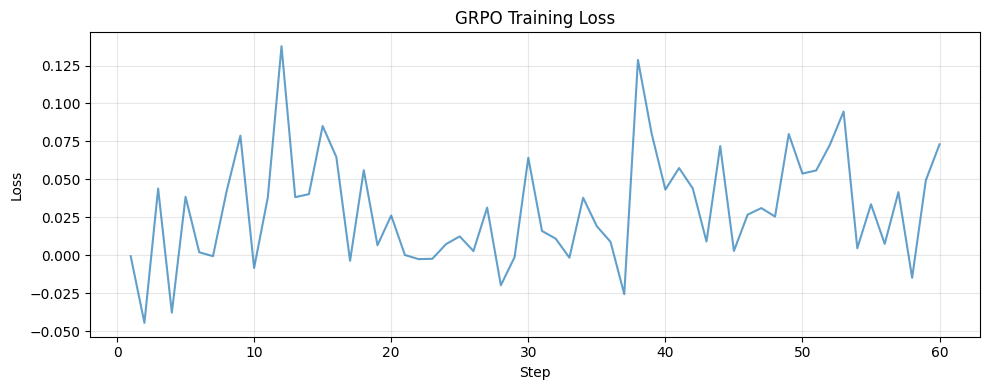

In [18]:
start_time = time.time()

try:
    trainer.train()
except KeyboardInterrupt:
    print("\nTraining interrupted — model state is recoverable.")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")

try:
    import matplotlib.pyplot as plt
    losses = [(e["step"], e["loss"]) for e in trainer.state.log_history if "loss" in e]
    if losses:
        steps, vals = zip(*losses)
        plt.figure(figsize=(10, 4))
        plt.plot(steps, vals, alpha=0.7)
        plt.xlabel("Step"); plt.ylabel("Loss")
        plt.title("GRPO Training Loss")
        plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
except ImportError:
    losses = [(e["step"], e["loss"]) for e in trainer.state.log_history if "loss" in e]
    for step, loss in losses[-10:]:
        print(f"  step {step}: {loss:.4f}")

---
## 11. Post-Training Evaluation

**What**: Re-run both evaluations on the trained model and print the comparison.

**Why**: Same puzzles, same sampling settings, same grader as the baseline —
only the adapter changed. Anything else would make the difference unreadable.

What a demo-scale run produced on this hardware:

| | baseline | trained | change |
|---|---|---|---|
| in-dist puzzles solved | 6% | **20%** | +14 points |
| in-dist cell accuracy | 0.306 | **0.506** | +0.199 |
| benchmark puzzles solved | 36% | 38% | +2 points |
| benchmark cell accuracy | 0.616 | 0.640 | +0.025 |
| parse rate (both sets) | 96–100% | 100% | — |

Read those two rows honestly. **In-distribution the gain is large** — the model
got substantially better at the phrasings it trained on. **On the benchmark it is
small but positive on every metric**, which is the more demanding result: the
skill transferred to sentences written by other people, rather than the model
merely memorising our generator's habits. Sixty steps is a rehearsal; the
literature's larger transfer gains come from runs an order of magnitude longer,
and from training data with more varied phrasing.

**How**: Both evaluations take a few minutes at demo scale. The target check at
the bottom is a guard-rail, not a grade — it tells you whether this run moved
enough to be worth registering.

In [22]:
print("Trained: in-distribution eval...")
trained_indist = evaluate_model(model, tokenizer, eval_puzzles)

print("\nTrained: ZebraLogic 5-house...")
trained_zlogic = (evaluate_model(model, tokenizer, zlogic_puzzles[:NUM_BENCH_PUZZLES])
                  if zlogic_puzzles else None)

# Comparison table
print(f"\n{'':26s} {'baseline':>10s} {'trained':>10s} {'delta':>10s}")
print(f"{'='*58}")

for label, base, trained in [("in-dist", baseline_indist, trained_indist),
                             ("zlogic", baseline_zlogic, trained_zlogic)]:
    if not (base and trained):
        continue
    for metric, fmt in [("puzzle_acc", "{:9.0%}"), ("cell_acc", "{:10.3f}"),
                        ("parse_rate", "{:9.0%}")]:
        d = trained[metric] - base[metric]
        print(f"{label + '  ' + metric:26s} "
              f"{fmt.format(base[metric]):>10s} {fmt.format(trained[metric]):>10s} "
              f"{('+' if d >= 0 else '') + fmt.format(d).strip():>10s}")

d_solved = trained_indist["puzzle_acc"] - baseline_indist["puzzle_acc"]
d_cell = trained_indist["cell_acc"] - baseline_indist["cell_acc"]
print()
if d_solved >= 0.10 or d_cell >= 0.10:
    print(f"In-dist target MET: solved {d_solved:+.0%} / cell {d_cell:+.3f}")
else:
    print(f"In-dist target NOT met: solved {d_solved:+.0%} / cell {d_cell:+.3f} (want +10% either)")

if baseline_zlogic and trained_zlogic:
    d_z = trained_zlogic["cell_acc"] - baseline_zlogic["cell_acc"]
    print(f"ZebraLogic transfer: cell {d_z:+.3f} "
          f"({'positive transfer' if d_z > 0 else 'no transfer yet'})")

Trained: in-distribution eval...


  32/50, cell_acc=0.496


  50/50, cell_acc=0.506

Trained: ZebraLogic 5-house...


  32/50, cell_acc=0.622


  50/50, cell_acc=0.640

                             baseline    trained      delta
in-dist  puzzle_acc                6%        20%       +14%
in-dist  cell_acc               0.306      0.506     +0.199
in-dist  parse_rate              100%       100%        +0%
zlogic  puzzle_acc                36%        38%        +2%
zlogic  cell_acc                0.616      0.640     +0.025
zlogic  parse_rate                96%       100%        +4%

In-dist target MET: solved +14% / cell +0.199
ZebraLogic transfer: cell +0.025 (positive transfer)


---
## 12. What the Model Actually Learned

**What**: Take one unseen puzzle, show every clue beside the rule the model wrote
for it, and mark the solver's grid cell by cell against the truth.

**Why**: Aggregate numbers tell you *whether* it improved; this tells you *how*,
and it is where the interesting failures live. Typical things to look for:

- **Direction flips** — `left_of` where the clue said right, or arguments the
  right way round but the wrong rule type. The relation was understood, the
  orientation was not.
- **Invented rule types or fields** — the model reaching for a form the language
  does not have. These are skipped as invalid, and you can see the cost in the
  `invalid` count.
- **One bad rule, whole grid wrong** — a single contradictory rule can push the
  solver to a different arrangement entirely. That is the exponent from section 7
  made visible, and it is why per-clue accuracy is worth chasing.

**How**: Re-run the cell for a different sample; each run re-generates, so
different puzzles expose different weaknesses. This view is also the fastest way
to decide what a longer run should fix.

In [23]:
from IPython.display import display, Markdown

# One puzzle, clue by clue: what the trained model translated and what the
# solver deduced from it
pz = eval_puzzles[0]
tok = getattr(tokenizer, "tokenizer", tokenizer)
FastLanguageModel.for_inference(model)
text = tokenizer.apply_chat_template(
    [{"role": "user", "content": translation_prompt(pz)}],
    tokenize=False, add_generation_prompt=True, enable_thinking=False)
enc = tok(text, return_tensors="pt").to(model.device)
with torch.no_grad():
    out = model.generate(**enc, max_new_tokens=MAX_COMPLETION_LENGTH,
                         do_sample=True, temperature=EVAL_TEMPERATURE,
                         top_p=EVAL_TOP_P, top_k=EVAL_TOP_K,
                         pad_token_id=tok.pad_token_id)
reply = tok.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
FastLanguageModel.for_training(model)

rules = parse_rules(reply) or []
grid, n_valid, n_invalid = solve_rules(rules, pz) if rules else (None, 0, 0)

lines = ["### Clue → rule\n"]
for i, clue in enumerate(pz["clues"]):
    rule = json.dumps(rules[i]) if i < len(rules) else "(missing)"
    lines.append(f"- {clue}\n  - `{rule}`")
lines.append(f"\n**Solver:** valid={n_valid} invalid={n_invalid} "
             f"acc={grade_grid(grid, pz):.2f}")
if grid:
    lines.append("\n| house | " + " | ".join(grid.keys()) + " |")
    lines.append("|" + "---|" * (len(grid) + 1))
    for i in range(pz["N"]):
        marks = []
        for c in grid:
            ok = grid[c][i] and grid[c][i].lower() == pz["solution"][c][i].lower()
            marks.append(f"{grid[c][i]} {'✓' if ok else '✗'}")
        lines.append(f"| {i+1} | " + " | ".join(marks) + " |")
display(Markdown("\n".join(lines)))

### Clue → rule

- The Old Gold is somewhere to the right of the red.
  - `{"type": "left_of", "a": ["smoke", "Old Gold"], "b": ["color", "red"]}`
- The Chesterfields is immediately to the right of the Parliaments.
  - `{"type": "immediate_right", "a": ["smoke", "Parliaments"], "b": ["smoke", "Chesterfields"]}`
- The Kools is in the same house as the milk.
  - `{"type": "same", "a": ["smoke", "Kools"], "b": ["drink", "milk"]}`
- The zebra is somewhere to the left of the ivory.
  - `{"type": "left_of", "a": ["pet", "zebra"], "b": ["color", "ivory"]}`
- The Kools is somewhere to the left of the water.
  - `{"type": "left_of", "a": ["smoke", "Kools"], "b": ["drink", "water"]}`
- The Englishman is immediately to the left of the Japanese.
  - `{"type": "immediate_left", "a": ["nationality", "Englishman"], "b": ["nationality", "Japanese"]}`
- The dog is in the first house.
  - `{"type": "same", "a": ["pet", "dog"], "b": ["house", 1]}`
- There is one house between the dog and the horse.
  - `{"type": "one_between", "a": ["pet", "dog"], "b": ["pet", "horse"]}`
- The Englishman is in the same house as the yellow.
  - `{"type": "same", "a": ["nationality", "Englishman"], "b": ["color", "yellow"]}`
- There is one house between the milk and the Spaniard.
  - `{"type": "one_between", "a": ["drink", "milk"], "b": ["nationality", "Spaniard"]}`
- The ivory is in the same house as the milk.
  - `{"type": "same", "a": ["color", "ivory"], "b": ["drink", "milk"]}`
- The red is immediately to the right of the Norwegian.
  - `{"type": "immediate_right", "a": ["nationality", "Norwegian"], "b": ["color", "red"]}`
- The dog is in the same house as the tea.
  - `{"type": "same", "a": ["pet", "dog"], "b": ["drink", "tea"]}`
- There are two houses between the snail and the green.
  - `{"type": "two_between", "a": ["pet", "snail"], "b": ["color", "green"]}`
- The blue is in the same house as the coffee.
  - `{"type": "same", "a": ["color", "blue"], "b": ["drink", "coffee"]}`

**Solver:** valid=14 invalid=1 acc=0.36

| house | color | nationality | drink | pet | smoke |
|---|---|---|---|---|---|
| 1 | blue ✗ | Spaniard ✗ | coffee ✗ | zebra ✗ | Lucky Strike ✗ |
| 2 | yellow ✗ | Englishman ✗ | orange juice ✓ | snail ✗ | Old Gold ✗ |
| 3 | ivory ✓ | Japanese ✗ | milk ✓ | horse ✓ | Kools ✓ |
| 4 | red ✓ | Ukrainian ✓ | water ✓ | fox ✓ | Chesterfields ✗ |
| 5 | green ✗ | Norwegian ✗ | tea ✗ | dog ✗ | Parliaments ✗ |

---
## 13. Save the Adapter

**What**: Write the LoRA adapter next to the notebook.

**Why**: This is the actual product of the training — roughly 60 MB of adapter
weights, not a 9 GB model. It only means anything alongside the base model it was
trained on, which is why the config records that pairing. Keeping the adapter
separate is what makes fine-tunes cheap to store and to share: one base model on
disk, many adapters beside it.

**How**: Local to this pod. The next section is what turns it into something the
rest of the cluster can use.

In [24]:
import os

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

abs_path = os.path.abspath(OUTPUT_DIR)
print(f"LoRA adapter saved to: {abs_path}")
print(f"Contents: {os.listdir(abs_path)}")

[transformers] Unsloth: Restored added_tokens_decoder metadata in ./zebra_rules_qwen35_4b/tokenizer_config.json.


LoRA adapter saved to: /home/thinkube/thinkube/notebooks/examples/zebra-grpo/zebra_rules_qwen35_4b
Contents: ['README.md', 'adapter_config.json', 'adapter_model.safetensors', 'chat_template.jinja', 'checkpoint-60', 'processor_config.json', 'tokenizer.json', 'tokenizer_config.json']


---
## 14. Close the Loop: Register the Fine-Tune in MLflow

**What**: Merge the adapter into the base weights and put the result in the
MLflow Model Registry.

**Why merge**: an adapter needs its base model and a library that knows how to
apply it. A merged checkpoint is an ordinary model directory that any serving
stack can open — which is what the vLLM backend in the next section expects. The
merge costs ~9 GB of disk and a few minutes of arithmetic.

**Why register**: this is the step that turns a file in your pod into a platform
asset. The registry entry lives on JuiceFS, so **every GPU node can read it** —
the same property that made mirroring worthwhile in section 3, now applied to
your own model. It gains a version, a run, the parameters that produced it, and
a place in the catalogue alongside the models you downloaded.

**How it works**: the merged model is written to the MLflow staging area, its
files are uploaded through the same S3 gateway MLflow itself uses, and a model
version is created pointing at them. thinkube-control also offers
`register_finetuned_model`, which runs the same steps as an Argo workflow if you
would rather not hold the notebook open.

**What you get**: `zebra-rules-qwen35-4b`, version 1, visible in MLflow and —
once it is in the model catalogue — loadable like any other model.

In [32]:
import base64
import os
from pathlib import Path
import boto3
from boto3.s3.transfer import TransferConfig
from botocore.config import Config as BotoConfig
import mlflow
from mlflow import MlflowClient
from kubernetes import client as k8s_client, config as k8s_config
import thinkube_models as tkm

FINETUNED_NAME = "zebra-rules-qwen35-4b"

# Merge the LoRA into the base weights; save an HF-format checkpoint to the
# MLflow staging area on JuiceFS
staging_dir = tkm.STAGING_PATH / FINETUNED_NAME
if not (staging_dir / "config.json").exists():
    model.save_pretrained_merged(str(staging_dir), tokenizer, save_method="merged_16bit")
print(f"Merged model in staging: {staging_dir}")

# The platform's register workflow reads staging from a private volume that
# JupyterHub cannot reach, so the notebook registers directly: it uploads the
# files through the same S3 gateway MLflow uses (credentials read with the
# pod's service account) and creates the registry entry itself.
k8s_config.load_incluster_config()
sec = k8s_client.CoreV1Api().read_namespaced_secret("mlflow-s3-secret", "mlflow")
creds = {k: base64.b64decode(v).decode() for k, v in sec.data.items()}

s3 = boto3.client(
    "s3",
    endpoint_url=creds["S3_ENDPOINT_URL"],
    aws_access_key_id=creds["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=creds["AWS_SECRET_ACCESS_KEY"],
    region_name="us-east-1",
    config=BotoConfig(request_checksum_calculation="when_required",
                      s3={"payload_signing_enabled": False}),
)
transfer = TransferConfig(multipart_threshold=64 * 2**20,
                          multipart_chunksize=64 * 2**20, max_concurrency=4)

os.environ["MLFLOW_TRACKING_TOKEN"] = tkm.get_mlflow_token() or ""
mlflow.set_tracking_uri("http://mlflow.mlflow.svc.cluster.local:5000")
client = MlflowClient()

exp = mlflow.get_experiment_by_name("finetuned-models")
exp_id = exp.experiment_id if exp else mlflow.create_experiment("finetuned-models")
mlflow.set_experiment("finetuned-models")

with mlflow.start_run(run_name=f"register-{FINETUNED_NAME}") as run:
    run_id = run.info.run_id
    mlflow.log_params({
        "source": "finetuned",
        "base_model": MODEL_NAME,
        "task": "text-generation",
        "server_type": "vllm",
        "description": "Qwen3.5-4B GRPO-tuned to translate zebra-puzzle clues into formal rules",
        "source_path": FINETUNED_NAME,
        "username": "thinkube",
    })

prefix = f"artifacts/{exp_id}/{run_id}/artifacts/model"
files = sorted(p for p in Path(staging_dir).rglob("*") if p.is_file())
print(f"Uploading {len(files)} files to s3://mlflow/{prefix}")
for i, p in enumerate(files, 1):
    key = f"{prefix}/{p.relative_to(staging_dir)}"
    size_gb = p.stat().st_size / 2**30
    if size_gb > 0.06:
        print(f"  {p.name} ({size_gb:.1f} GB)...")
    s3.upload_file(str(p), "mlflow", key, Config=transfer)
print("Upload complete")

try:
    client.create_registered_model(FINETUNED_NAME)
except Exception:
    pass
version = client.create_model_version(
    name=FINETUNED_NAME,
    source=f"s3://mlflow/{prefix}",
    run_id=run_id,
)
print(f"Registered {FINETUNED_NAME} version {version.version} (run {run_id})")

Merged model in staging: /home/thinkube/thinkube/mlflow/.staging/zebra-rules-qwen35-4b


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'auth.thinkube.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


🏃 View run register-zebra-rules-qwen35-4b at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3/runs/0f7d4c2a6d1e4a109ab27306dd59d062
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3
Uploading 8 files to s3://mlflow/artifacts/3/0f7d4c2a6d1e4a109ab27306dd59d062/artifacts/model


  model.safetensors-00001-of-00002.safetensors (5.0 GB)...


  model.safetensors-00002-of-00002.safetensors (3.7 GB)...


2026/08/27 07:40:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: zebra-rules-qwen35-4b, version 1


Upload complete
Registered zebra-rules-qwen35-4b version 1 (run 0f7d4c2a6d1e4a109ab27306dd59d062)


---
## 15. Serve It Through the LLM Gateway

**What**: Load the fine-tune onto a vLLM backend and query it the way any
application would.

**Why this is the real finish line**: everything before this produced artifacts.
This produces a *service*. The same `tk-llm` client that notebooks 01–03 used to
call the platform's stock models now calls **your** model, through the same
OpenAI-compatible endpoint, with no special casing anywhere. A fine-tune stops
being a research output at exactly the moment other code can reach it.

Note the shape of the final query: the gateway returns rules, and the **solver**
finishes the job locally. That is the deployed form of the pattern this notebook
has been building — the model formalizes, the machine deduces — and the reason
the answer can be trusted: the solver cannot produce a grid that violates the
rules it was given.

**How**: The load needs a target node. The cell picks one that has a free slot
*and* reports GPU metrics — the scheduler refuses to place a model on a node it
cannot measure, which is a deliberate safety property, not an obstacle to work
around. Loading takes a few minutes while vLLM reads the weights and warms up;
the loop polls until the state turns `available`.

**Before you register a model of your own**: the catalogue is what the serving
registry reads, so a fine-tune becomes loadable once it has an entry there
(`thinkube-metadata/models.json`, `server_type: ["vllm"]`, `is_finetuned: true`).
Unload it from thinkube-control → AI → Models when you are done, so the GPU goes
back to the pool.

In [39]:
import time
from tk_llm import LLMClient, get_openai_client

llm = LLMClient()

# Pick a GPU node the scheduler can verify (metrics available) with a free slot
opts = llm.get_load_options(FINETUNED_NAME)
node = next(n.name for n in opts.gpu_nodes
            if n.available_slots > 0 and getattr(n, "metrics_available", True))
print(llm.load_model(FINETUNED_NAME, node=node))

# Wait until the backend reports the model as available
for _ in range(60):
    status = llm.get_model_status(FINETUNED_NAME)
    if str(status.model.state) in ("ModelState.available", "available"):
        break
    time.sleep(10)
print("state:", status.model.state, "backend:", status.model.backend_id)

# The served fine-tune, reached through the LLM gateway from any client:
# translate a fresh puzzle's clues, then let the local solver finish the job
client = get_openai_client()
pz = eval_puzzles[1]
reply = client.chat.completions.create(
    model=FINETUNED_NAME,
    messages=[{"role": "user", "content": translation_prompt(pz)}],
    extra_body={"chat_template_kwargs": {"enable_thinking": False}},
)
text = reply.choices[0].message.content
rules = parse_rules(text) or []
grid, n_valid, n_invalid = solve_rules(rules, pz) if rules else (None, 0, 0)
print(f"Gateway translation: {len(rules)} rules, valid={n_valid}, "
      f"acc={grade_grid(grid, pz):.2f}")

model_id='zebra-rules-qwen35-4b' state=<ModelState.loading: 'loading'> message='Loading model — this may take several minutes' backend_id='vllm-tkspark'


state: ModelState.available backend: vllm-tkspark


Gateway translation: 15 rules, valid=15, acc=0.72


---
## [Optional] Export to GGUF

**What**: Convert the merged model to GGUF, the format Ollama and llama.cpp read.

**Why**: vLLM serves this model well on a datacentre GPU. GGUF is the other end
of the spectrum — quantised weights that run on a laptop or a small edge box, at
some cost in quality. If the point of fine-tuning a 4B model was to deploy it
somewhere modest, this is the last step.

**How**: Left commented on purpose. Unsloth's GGUF export is best-effort for
architectures as recent as Qwen3.5, and a failure here should not interrupt a
successful run. Uncomment when you need it, and treat a conversion error as
"not yet supported" rather than as a problem with your training.

In [ ]:
# Uncomment to export:
# model.save_pretrained_gguf("zebra_gguf", tokenizer, quantization_method="q4_k_m")
# print("GGUF export complete.")

---
## 🎓 Summary: You Taught a Model to Formalize

### ✅ What you accomplished

- **Built a verifiable task** — a puzzle generator that produces its own ground
  truth, and a rule language a constraint solver can execute
- **Trained with no labelled data** — the reward came from running a solver on
  the model's output and counting correct cells, not from example answers
- **Measured honestly** — a cached baseline, two evaluation sets, and a public
  benchmark the model never trained on
- **Improved a 4B model past a 9B one** on this task: the trained 4B scores
  higher than the untrained 9B did, at half the serving cost
- **Closed the loop** — merged, registered in MLflow, served on vLLM, queried
  through the LLM Gateway like any other platform model

### 🔁 The pattern, beyond puzzles

The model never solved a puzzle. It turned sentences into structure, and a
machine did the rest. That division of labour is the useful part, and it
transfers:

| task | what the model emits | what verifies it |
|---|---|---|
| **Knowledge graphs** | `(entity, relation, entity)` triples | ontology and consistency checks |
| **Text to query** | SQL or a graph query | the query runs and returns the right rows |
| **Document extraction** | invoice / contract / clinical fields | schema validation, checksums, totals |
| **Policy to rules** | executable compliance checks | the checks run against known cases |

Swap the rule language for your schema and the solver for your validator, and the
training loop here is unchanged. The hard part of applying RL to real work is
finding a grader that cannot be fooled — which is exactly what these four
examples have.

### 🚀 Next steps

- **Train longer** — set `FULL_RUN = True`. Whole-puzzle accuracy behaves roughly
  like per-clue accuracy to the fifteenth power, so lifting translation from ~90%
  to ~95% correct per rule would take solved puzzles from 20% to around 45%.
- **Widen the phrasing** — add clue templates to `zebra_dataset.py`. Benchmark
  transfer is limited by how many ways the training data says the same thing.
- **Try the 9B** — change `MODEL_NAME` to `unsloth/Qwen3.5-9B`. It starts
  stronger; it also trains and serves more slowly. Worth measuring rather than
  assuming.
- **Take it to your own data** — the section above is the map.

---

**Licence**: Apache-2.0. Copyright (c) 2026 Thinkube Contributors.
SPDX-License-Identifier: Apache-2.0

Built with [Unsloth](https://github.com/unslothai/unsloth) (Apache-2.0) and
[TRL](https://github.com/huggingface/trl) (Apache-2.0). Puzzle generation and
scoring by the accompanying `zebra_dataset.py`. The formalize-then-solve approach
follows the neuro-symbolic literature — Logic-LM, SatLM, LINC.

**Benchmark citation:**

```
ZebraLogic: Lin, B.Y., Le Bras, R., Choi, Y. (2024).
ZebraLogic: Benchmarking the Logical Reasoning Ability of Language Models.
https://huggingface.co/datasets/WildEval/ZebraLogic
```